In [ ]:
%load_ext autoreload
%autoreload 2

import xarray as xr
import xvec
import zarr
import s3fs
import os
import matplotlib.pyplot as plt
import pandas as pd

# Xarray dark mode hack
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))

In [2]:
fs = s3fs.S3FileSystem(
    key=os.environ["AWS_ACCESS_KEY_ID"],
    secret=os.environ["AWS_SECRET_ACCESS_KEY"],
    client_kwargs={"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    config_kwargs={
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
                }
)

storage_options = {
    "client_kwargs": {"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    "config_kwargs": {
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
    },
}

In [14]:
# meltwater = xr.open_dataset('s3://gaia/cjense/data/mar/basin_meltwater_ZI.zarr', storage_options=storage_options, consolidated=False)
meltwaterds = xr.open_dataset('s3://gaia/cjense/data/testmodel/meltwater_regridded_daily_clipped_2015_onward.zarr', consolidated=False, storage_options=storage_options)
meltwaterds = meltwaterds.chunk(chunks={"TIME": 100, "x": 50, "y": 50})
meltwaterds = meltwaterds.RU.drop_vars(['SECTOR', 'spatial_ref', 'crs', 'name'])
meltwater = meltwaterds.to_dask_dataframe()
# meltwater = meltwater.reset_index()
# meltwater = meltwater.rename(columns={"TIME":'time'})
# meltwater.to_parquet("s3://gaia/cjense/data/testmodel/meltwater_ZI.parquet", storage_options=storage_options)
meltwater

,x,y,TIME,SECTOR,RU
npartitions=5916,,,,,
0,float64,float64,datetime64[ns],int64,float32
465508,...,...,...,...,...
...,...,...,...,...,...
2796996792,...,...,...,...,...
2797470325,...,...,...,...,...


In [ ]:
meltwater = meltwater.rename(columns={"TIME":'time'})
meltwater = meltwater.drop(columns=['SECTOR', 'RU'])
meltwater

,x,y,time
npartitions=5916,,,
0,float64,float64,datetime64[ns]
465508,...,...,...
...,...,...,...
2796996792,...,...,...
2797470325,...,...,...


In [19]:
meltwater.to_parquet("s3://gaia/cjense/data/testmodel/meltwater_ZI_clipped_2015_onward.parquet", storage_options=storage_options)

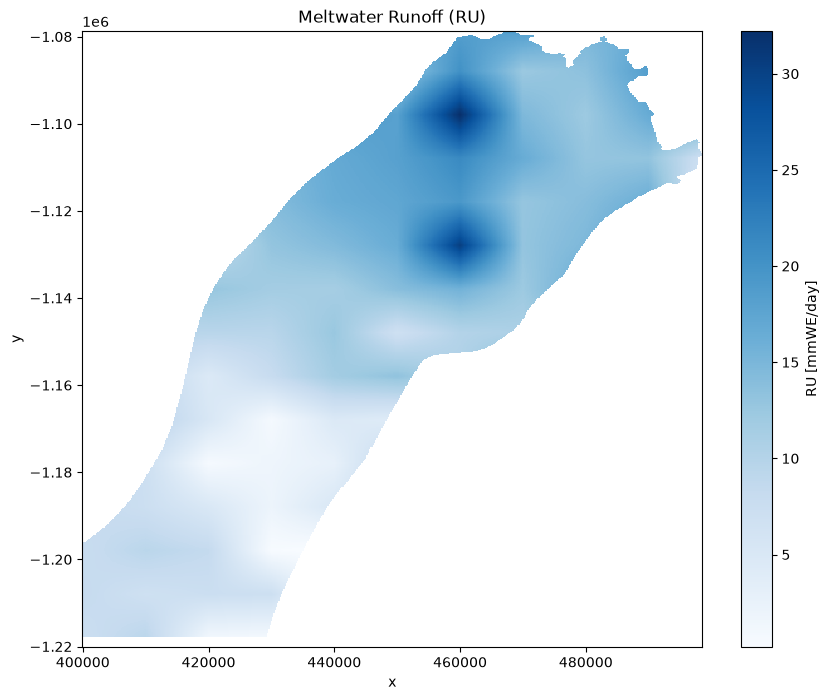

In [6]:
# plot_date = "2025-06-15"

ru_day = meltwater.sel(TIME='2020-07-10T12:00:00.000000000', method="nearest").mean(dim="SECTOR")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    ru_day.x,
    ru_day.y,
    ru_day,
    cmap="Blues",
    shading="auto",
)
fig.colorbar(im, ax=ax, label=f"RU [{ru_day.attrs.get('units', '')}]")

# ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Meltwater Runoff (RU)")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()

In [3]:
velocity = xr.open_dataset('s3://gaia/cjense/data/velocity/basin_velocity_ZI.zarr', consolidated=False, storage_options=storage_options)
velocity = velocity.VelocityMap
velocity = velocity.sel(band='vv')
velocity = velocity.drop_vars(['band', '_FillValue', 'name'])
velocity = velocity.to_dataframe()

VelocityMap
time                y          x                    
2014-12-16 00:00:00 -1078800.0 400000.0          NaN
                               400200.0          NaN
                               400400.0          NaN
                               400600.0          NaN
                               400800.0          NaN
...                                              ...
2025-12-21 12:00:00 -1220000.0 497600.0          NaN
                               497800.0          NaN
                               498000.0          NaN
                               498200.0          NaN
                               498400.0          NaN

[174624051 rows x 1 columns]

In [4]:
velocity = velocity.reset_index()
velocity.to_parquet("s3://gaia/cjense/data/testmodel/velocity_ZI.parquet", storage_options=storage_options)
velocity

,time,y,x,VelocityMap
0,2014-12-16 00:00:00,-1078800.0,400000.0,NaN
1,2014-12-16 00:00:00,-1078800.0,400200.0,NaN
2,2014-12-16 00:00:00,-1078800.0,400400.0,NaN
3,2014-12-16 00:00:00,-1078800.0,400600.0,NaN
4,2014-12-16 00:00:00,-1078800.0,400800.0,NaN
...,...,...,...,...
174624046,2025-12-21 12:00:00,-1220000.0,497600.0,NaN
174624047,2025-12-21 12:00:00,-1220000.0,497800.0,NaN
174624048,2025-12-21 12:00:00,-1220000.0,498000.0,NaN
174624049,2025-12-21 12:00:00,-1220000.0,498200.0,NaN


In [21]:
velocity = pd.read_parquet("s3://gaia/cjense/data/testmodel/velocity_ZI.parquet", storage_options=storage_options)

In [22]:
velocity["time"] = pd.to_datetime(velocity["time"]).dt.normalize()
meltwater["time"] = pd.to_datetime(meltwater["time"]).dt.normalize()

merged = pd.merge(velocity, meltwater, on=["x", "y", "time"], how="right")

: 

In [29]:
merged = merged.set_index('time')
merged = merged.drop(columns='index')

In [30]:
merged

,y,x,VelocityMap,RU
time,,,,
1999-12-30,-1078800.0,400000.0,NaN,NaN
1999-12-30,-1078800.0,400200.0,NaN,NaN
1999-12-30,-1078800.0,400400.0,NaN,NaN
1999-12-30,-1078800.0,400600.0,NaN,NaN
1999-12-30,-1078800.0,400800.0,NaN,NaN
...,...,...,...,...
2000-02-17,-1220000.0,497600.0,NaN,NaN
2000-02-17,-1220000.0,497800.0,NaN,NaN
2000-02-17,-1220000.0,498000.0,NaN,NaN


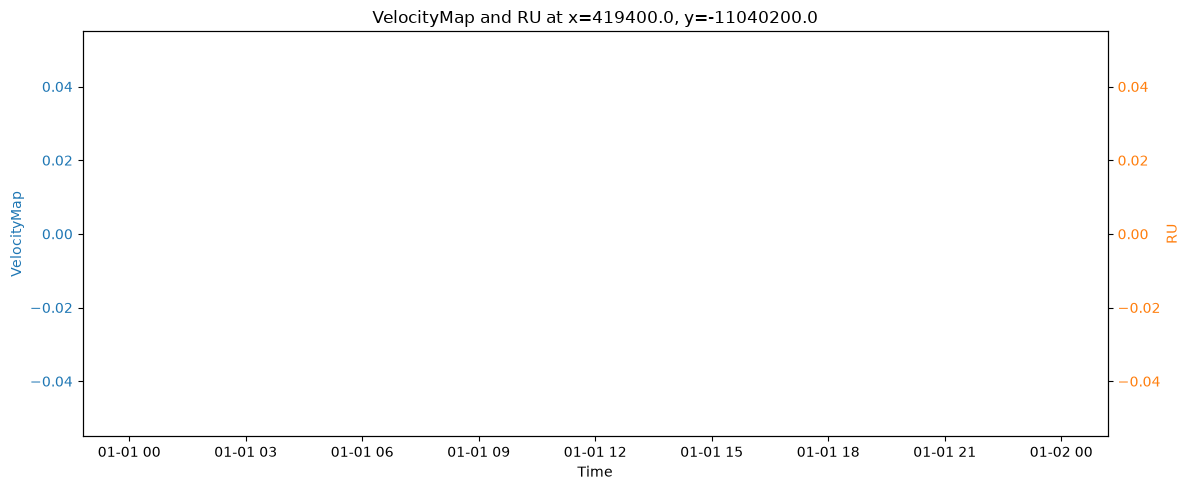

In [32]:
x_coord = 419400.0
y_coord = -11040200.0

point = (
    merged.loc[
        (merged["x"] == x_coord) &
        (merged["y"] == y_coord),
        ["VelocityMap", "RU"],
    ]
    .sort_index()
)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(point.index, point["VelocityMap"], label="VelocityMap", color="tab:blue")
ax1.set_xlabel("Time")
ax1.set_ylabel("VelocityMap", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(point.index, point["RU"], label="RU", color="tab:orange")
ax2.set_ylabel("RU", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax1.set_title(f"VelocityMap and RU at x={x_coord}, y={y_coord}")
fig.tight_layout()
plt.show()